In [302]:
from transformers import pipeline
from google.colab import userdata
import pandas as pd
from huggingface_hub import notebook_login
import json
import os
from google import genai
import numpy as np
from pydantic import BaseModel, Field
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
os.chdir("ANP/")

In [7]:
client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

In [8]:
notebook_login()

In [9]:
pipeline = pipeline("text-classification",model = "umich/bert-sentiment-nuclear")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [10]:
with open("data/raw_nuclear.json","r") as f:
  data = json.load(f)

In [168]:
df = pd.read_csv("data/data_tickers.csv")
df.head()

,Price,Close,Close.1,Close.2,Close.3,High,High.1,High.2,High.3,Low,...,Low.2,Low.3,Open,Open.1,Open.2,Open.3,Volume,Volume.1,Volume.2,Volume.3
0,Ticker,NLR,NUKZ,URA,URNM,NLR,NUKZ,URA,URNM,NLR,...,URA,URNM,NLR,NUKZ,URA,URNM,NLR,NUKZ,URA,URNM
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-05-18,127.52999877929688,68.41000366210938,48.68000030517578,58.75,130.75,69.9800033569336,50.369998931884766,60.79999923706055,126.08000183105469,...,48.040000915527344,58.13999938964844,130.75,69.9800033569336,50.04999923706055,60.33000183105469,518700,173400,3970400,683500
3,2026-05-19,125.05999755859375,67.12999725341797,47.20000076293945,57.08000183105469,126.72000122070312,67.87000274658203,48.11000061035156,58.77000045776367,123.58000183105469,...,46.560001373291016,56.689998626708984,126.58999633789062,67.63999938964844,47.959999084472656,58.77000045776367,483200,131900,3571000,977900
4,2026-05-20,127.83999633789062,68.79000091552734,48.040000915527344,57.43000030517578,128.47000122070312,69.0,48.47999954223633,58.220001220703125,125.25,...,47.0099983215332,56.810001373291016,126.52999877929688,67.88999938964844,47.529998779296875,57.720001220703125,484900,98500,3032400,344400


In [169]:
df = df.reset_index().set_index('index')
df = df.T
cols = df[df.index =='Price'].loc['Price'].to_list()
df.columns = list(cols)
df = df[1::][::]

In [291]:
cols = ['Close','High','Low','Open','Volume']
tickers = df.Ticker.unique()
df_1 = pd.DataFrame()
i = 0
for ticker in tickers:
  df_ticker = df[df.Ticker == ticker]
  df_ticker = df_ticker.T[::][2::].reset_index().rename(columns = {'index': 'Date'})
  df_ticker['Ticker'] = pd.Series()
  df_ticker['Ticker'] = ticker

  if i > 0:
    cols_t = [f"{x}.{i}" for x in cols]
    df_ticker.rename(columns = dict(zip(cols_t,cols)), inplace= True)

  df_1 = pd.concat([df_1,df_ticker])
  i += 1

df_1['Date'] = pd.to_datetime(df_1['Date'])
df_1 = df_1.sort_values(by = 'Date').reset_index().drop(columns = 'index')
df_1.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2026-05-18,127.52999877929688,130.75,126.08000183105469,130.75,518700,NLR
1,2026-05-18,48.68000030517578,50.369998931884766,48.040000915527344,50.04999923706055,3970400,URA
2,2026-05-18,58.75,60.79999923706055,58.13999938964844,60.33000183105469,683500,URNM
3,2026-05-18,68.41000366210938,69.9800033569336,67.5199966430664,69.9800033569336,173400,NUKZ
4,2026-05-19,47.20000076293945,48.11000061035156,46.560001373291016,47.959999084472656,3571000,URA


In [11]:
scores = []
for k in range(len(data['articles'])):
  scores.append(pipeline(data['articles'][k]['content'])

In [12]:
reference = data['articles']
prompt = f"""

Check the content of each article in {reference} and indicate whether they are contain the
word nuclear.


"""

schema = {
    "article_title" : {
        "type" : "string",
        "description" : "The title of the article"
    },
    "is_contain_nuclear" : {
        "type" : "boolean",
        "description" : "Whether the article contains the word nuclear"
    }
}

response = client.models.generate_content(
    model = "gemini-2.5-flash",
    contents = prompt,
    config = {
        'response_mime_type': "application/json",
        'response_json_schema': schema

    },
)



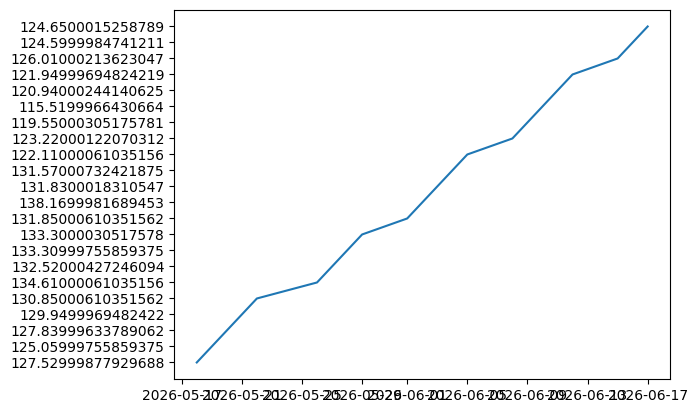

In [301]:
ls = df_1[df_1['Ticker']=='NLR'][['Date','Close','Ticker']]
plt.plot(ls.Date,ls.Close)
